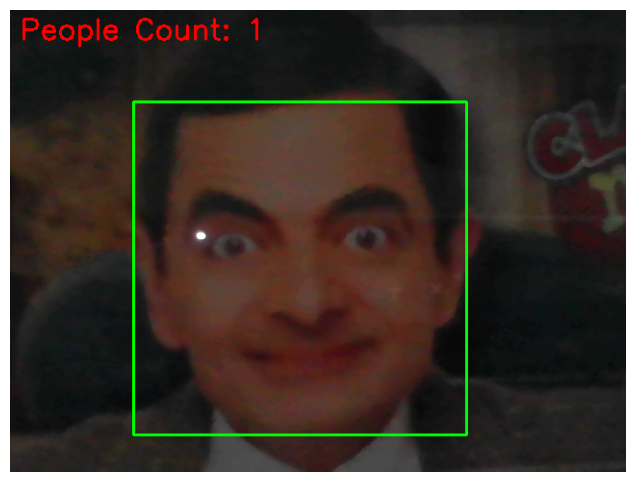

Time limit reached. Stopping camera...
Camera released successfully.


In [3]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Load Haar Cascade face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Start webcam
cap = cv2.VideoCapture(0)

# Set running time in seconds
RUN_TIME = 40   # Nearly one minute it runs, after that it shuts down. 

# Start timer
start_time = time.time()

while True:

    # Stop after RUN_TIME seconds
    if time.time() - start_time > RUN_TIME:
        print("Time limit reached. Stopping camera...")
        break

    # Read frame
    ret, frame = cap.read()

    if not ret:
        break

    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    # Count faces
    current_count = len(faces)

    # Draw rectangles
    for (x, y, w, h) in faces:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    # Show count
    cv2.putText(
        frame,
        f'People Count: {current_count}',
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Clear previous output
    clear_output(wait=True)

    # Display frame
    plt.figure(figsize=(8, 6))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    # Small delay
    time.sleep(0.1)

# Release camera
cap.release()

print("Camera released successfully.")